# Finding rich club nodes 
- Compute rich club nodes

In [1]:
# %matplotlib widget
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
import umap
from sklearn.linear_model import LinearRegression

%reload_ext autoreload
%autoreload 2

from tes.data_ingestion import DataRead
from tes.analysis import AnalysisFunc
from tes.algo_umap import UmapAlgo
from tes.algo_partial_full import AlgoParFull
import numpy as np
import pandas as pd
import statistics
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch
import matplotlib.colors as mcolors
from pathlib import Path
import glob

import networkx as nx
import seaborn as sns
from tes.DataUtils import DataUtils
from scipy.stats import mannwhitneyu
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import scipy.stats
from scipy.stats import spearmanr, linregress
import matplotlib.gridspec as gridspec

In [2]:
analyse = AnalysisFunc()
reader = DataRead()
utils = DataUtils()
algo = UmapAlgo()
algo_pf = AlgoParFull()

..\..\data\connectivity_matrix\mb_communities.npz already exists
DataUtils initialized


In [3]:
G = nx.from_numpy_array(utils.WHOLE_BRAIN_CONN)

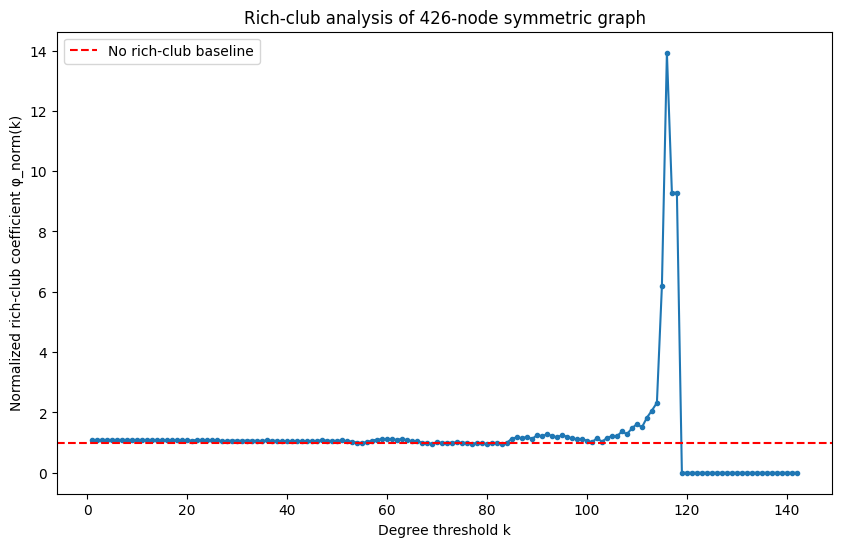

Rich-club threshold k* = 118
Number of rich-club nodes = 8
Rich-club nodes = [1, 2, 36, 137, 214, 215, 249, 350]


In [4]:


def rich_club_coefficient(G, k):
    nodes = [n for n, d in G.degree() if d > k]
    N = len(nodes)
    if N <= 1:
        return 0
    subgraph = G.subgraph(nodes)
    E = subgraph.number_of_edges()
    return (2 * E) / (N * (N - 1))

def normalized_rich_club(G, k, n_random=20):
    phi = rich_club_coefficient(G, k)
    deg_seq = [d for _, d in G.degree()]
    phi_rand = []
    for _ in range(n_random):
        R = nx.configuration_model(deg_seq)
        R = nx.Graph(R)  # remove parallel edges/self-loops
        R.remove_edges_from(nx.selfloop_edges(R))
        phi_rand.append(rich_club_coefficient(R, k))
    phi_rand_mean = np.mean(phi_rand)
    return phi / phi_rand_mean if phi_rand_mean > 0 else 0

# --- Run analysis ---
degrees = dict(G.degree())
max_degree = max(degrees.values())

k_values = range(1, max_degree)
phi_norm = {k: normalized_rich_club(G, k) for k in k_values}

# Plot φ_norm(k)
plt.figure(figsize=(10,6))
plt.plot(list(phi_norm.keys()), list(phi_norm.values()), marker='o', markersize=3)
plt.axhline(y=1, color='r', linestyle='--', label='No rich-club baseline')
plt.xlabel("Degree threshold k")
plt.ylabel("Normalized rich-club coefficient φ_norm(k)")
plt.title("Rich-club analysis of 426-node symmetric graph")
plt.legend()
plt.show()

# Identify rich-club nodes
rich_thresholds = [k for k, val in phi_norm.items() if val > 1]
if rich_thresholds:
    k_star = max(rich_thresholds)
    rich_nodes = [n for n, d in G.degree() if d > k_star]
    print("Rich-club threshold k* =", k_star)
    print("Number of rich-club nodes =", len(rich_nodes))
    print("Rich-club nodes =", rich_nodes)
else:
    print("No rich-club organization detected.")
